## 1. Load train set

In [2]:
import pandas as pd

X_train = pd.read_csv('Data/x_train.csv')
y_train = pd.read_csv('Data/y_train.csv')
print(f"Shape: {X_train.shape}")
X_train.head()

Shape: (5180, 32)


,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,Male,35,Yes,3,36.545353,-119.338535,2,34,Offer C,No,...,Yes,Month-to-Month,Yes,Bank Withdrawal,44.85,1442.60,0.0,0,0.00,1442.60
1,Male,75,Yes,0,35.480896,-120.469476,7,68,Offer A,Yes,...,Yes,One Year,Yes,Credit Card,80.35,5589.30,0.0,0,2333.08,7922.38
2,Female,80,Yes,0,34.083086,-117.737997,1,43,No Offer,Yes,...,No,One Year,Yes,Bank Withdrawal,107.55,4533.90,0.0,140,595.12,5269.02
3,Male,44,No,0,34.049671,-117.468896,0,1,No Offer,No,...,Yes,Month-to-Month,Yes,Mailed Check,24.45,24.45,0.0,0,0.00,24.45
4,Female,75,Yes,1,38.148862,-121.737696,8,57,No Offer,Yes,...,Yes,Month-to-Month,Yes,Credit Card,95.30,5567.45,0.0,0,1610.25,7177.70


## 2. Target variable

Churn
0        3709
1        1471
Name: count, dtype: int64

Churn
0        71.602317
1        28.397683
Name: proportion, dtype: float64


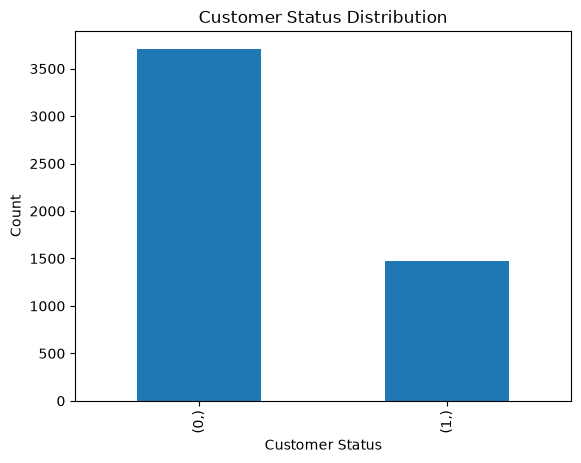

In [3]:
import matplotlib.pyplot as plt

print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True) * 100)

y_train.value_counts().plot(kind='bar')
plt.title('Customer Status Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Count')
plt.show()

## 3. Numeric feature distributions

In [4]:
X_train.describe()

,Age,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000
mean,46.872973,0.470849,36.221352,-119.767579,2.038224,34.788031,23.076347,20.969498,66.740396,2467.683697,2.031492,7.202703,807.355471,3280.210378
std,16.975639,0.964578,2.468243,2.153743,3.016414,23.976670,15.453032,20.326820,29.752212,2265.577639,8.022361,25.877036,858.215534,2851.691328
min,19.000000,0.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,18.250000,19.100000,0.000000,0.000000,0.000000,23.240000
25%,33.000000,0.000000,33.992416,-121.785559,0.000000,12.000000,9.210000,4.000000,44.087500,560.787500,0.000000,0.000000,111.100000,850.167500
50%,46.000000,0.000000,36.340961,-119.680720,0.000000,33.000000,23.155000,17.000000,73.625000,1634.975000,0.000000,0.000000,482.730000,2475.140000
75%,60.000000,0.000000,38.200231,-117.973758,3.000000,57.000000,36.490000,27.000000,90.800000,4055.812500,0.000000,0.000000,1290.425000,5177.277500
max,80.000000,9.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8672.450000,49.790000,150.000000,3564.720000,11868.340000


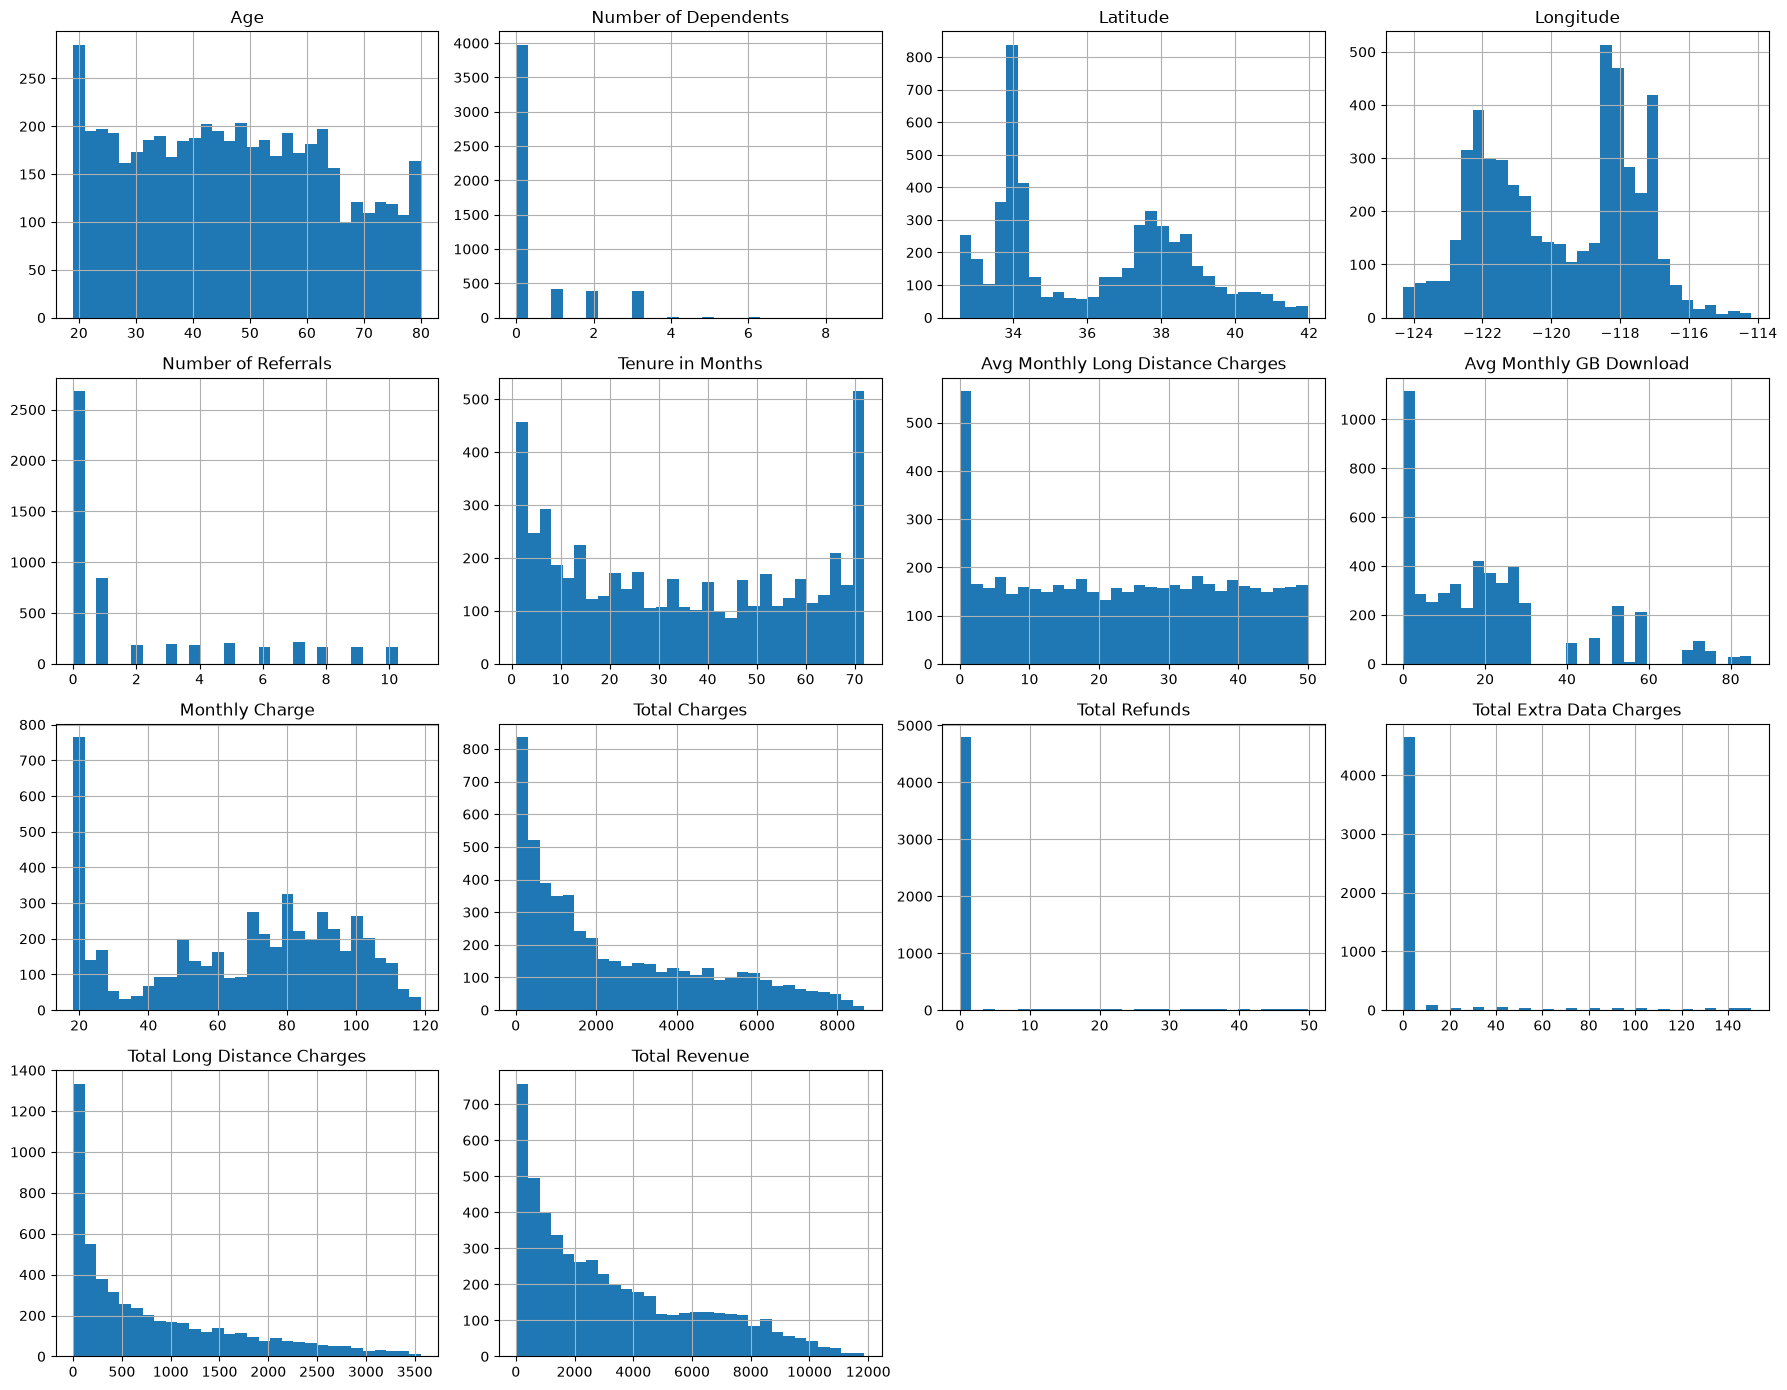

In [5]:
X_train.hist(bins=30, figsize=(18, 14))
plt.tight_layout()
plt.show()

## 4. Categorical feature distributions

In [6]:
X_train.describe(include='object')

C:\Users\Bahar\AppData\Local\Temp\ipykernel_12748\2541655948.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.describe(include='object')


,Gender,Married,Offer,Phone Service,Multiple Lines,Internet Service,Internet Type,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method
count,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180,5180
unique,2,2,6,2,3,2,4,3,3,3,3,3,3,3,3,3,2,3
top,Female,Yes,No Offer,Yes,No,Yes,Fiber Optic,No,No,No,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal
freq,2610,2638,2832,4687,2352,4153,2341,2601,2271,2258,2586,2108,2149,2199,3583,2498,3144,2958


## 5. Categorical features vs. churn

In [7]:
import pandas as pd

# combine for crosstab convenience
temp = X_train.copy()
temp['Churn'] = y_train['Churn'].values

pd.crosstab(temp['Contract'], temp['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-Month,48.318655,51.681345
One Year,88.669951,11.330049
Two Year,97.131148,2.868852


In [8]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"--- {col} ---")
    print((pd.crosstab(temp[col], temp['Churn'], normalize='index') * 100).round(1))
    print()

C:\Users\Bahar\AppData\Local\Temp\ipykernel_12748\2197220963.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


--- Gender ---
Churn      0     1
Gender            
Female  71.7  28.3
Male    71.5  28.5

--- Married ---
Churn       0     1
Married            
No       63.4  36.6
Yes      79.5  20.5

--- Offer ---
Churn        0     1
Offer               
No Offer  70.9  29.1
Offer A   92.7   7.3
Offer B   87.1  12.9
Offer C   76.6  23.4
Offer D   73.2  26.8
Offer E   32.8  67.2

--- Phone Service ---
Churn             0     1
Phone Service            
No             73.2  26.8
Yes            71.4  28.6

--- Multiple Lines ---
Churn                0     1
Multiple Lines              
No                72.0  28.0
No Phone Service  73.2  26.8
Yes               70.8  29.2

--- Internet Service ---
Churn                0     1
Internet Service            
No                91.9   8.1
Yes               66.6  33.4

--- Internet Type ---
Churn                   0     1
Internet Type                  
Cable                72.9  27.1
DSL                  79.9  20.1
Fiber Optic          58.1  41.9
No Inter

## 6. Investigating the `Offer E` anomaly

In [9]:
temp[temp['Offer'] == 'Offer E'][['Monthly Charge', 'Tenure in Months', 'Contract']].describe()

,Monthly Charge,Tenure in Months
count,491.000000,491.000000
mean,59.130652,4.234216
std,26.026434,2.778953
min,18.850000,1.000000
25%,35.700000,1.000000
50%,66.050000,4.000000
75%,80.050000,7.000000
max,109.900000,9.000000


## 7. Numeric features vs. churn

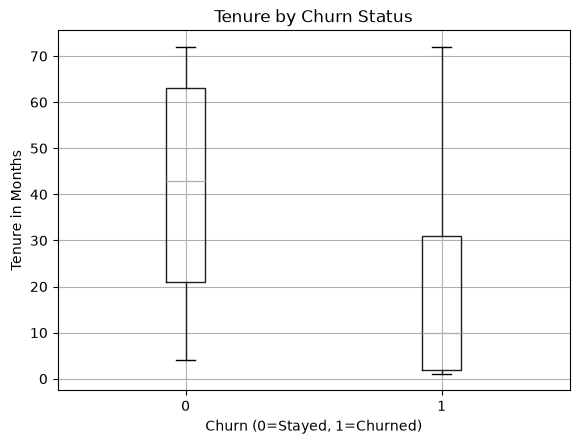

In [10]:
import matplotlib.pyplot as plt

temp.boxplot(column='Tenure in Months', by='Churn')
plt.title('Tenure by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Tenure in Months')
plt.show()

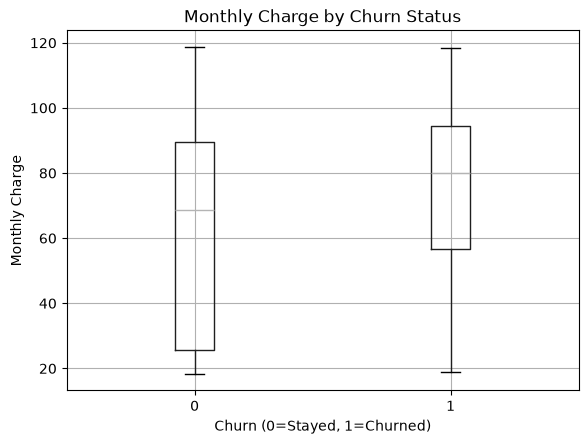

In [11]:
temp.boxplot(column='Monthly Charge', by='Churn')
plt.title('Monthly Charge by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Monthly Charge')
plt.show()

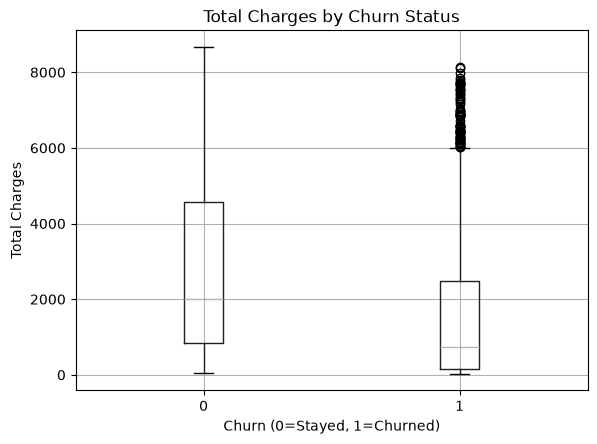

In [12]:
temp.boxplot(column='Total Charges', by='Churn')
plt.title('Total Charges by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Total Charges')
plt.show()

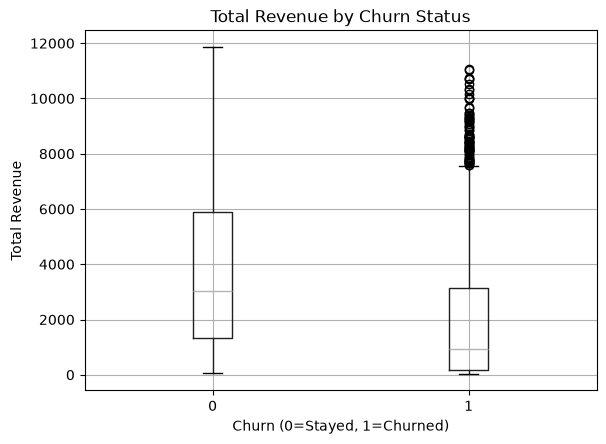

In [13]:
temp.boxplot(column='Total Revenue', by='Churn')
plt.title('Total Revenue by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Total Revenue')
plt.show()

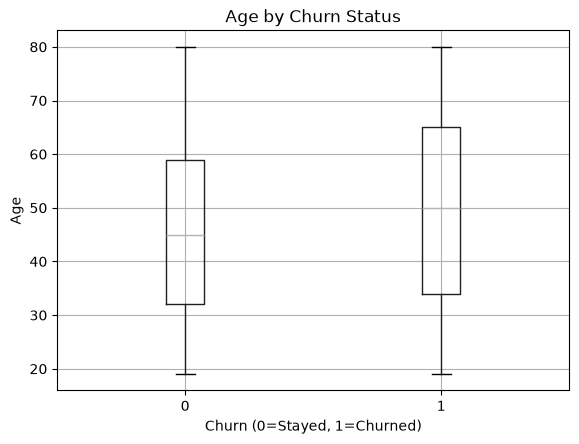

In [14]:
temp.boxplot(column='Age', by='Churn')
plt.title('Age by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Age')
plt.show()

## 8. Correlation and multicollinearity

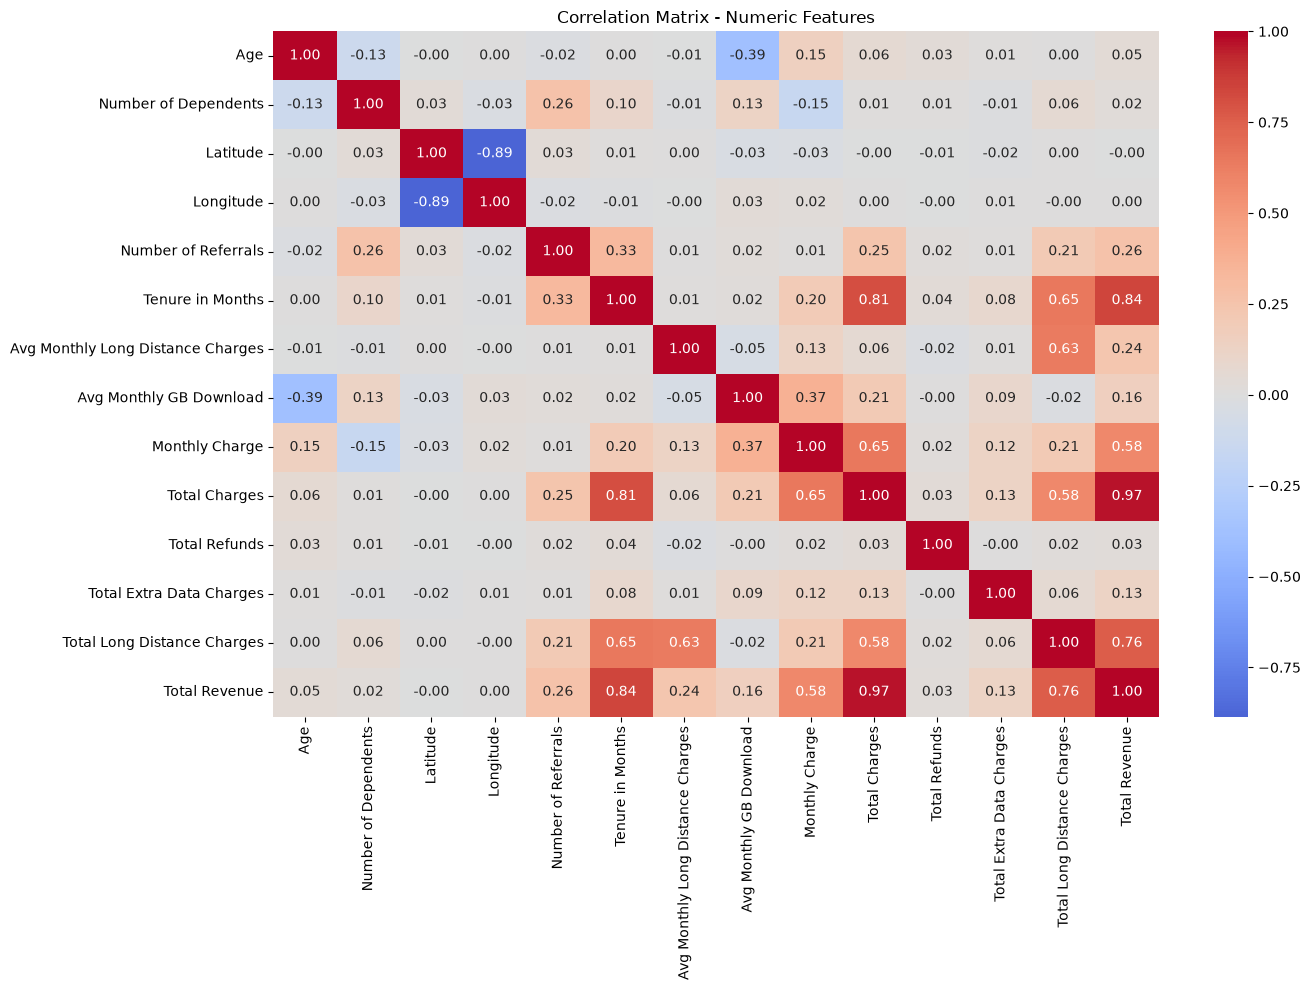

In [15]:
import seaborn as sns

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, 10))
sns.heatmap(X_train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

## 9. Geographic signal and feature engineering

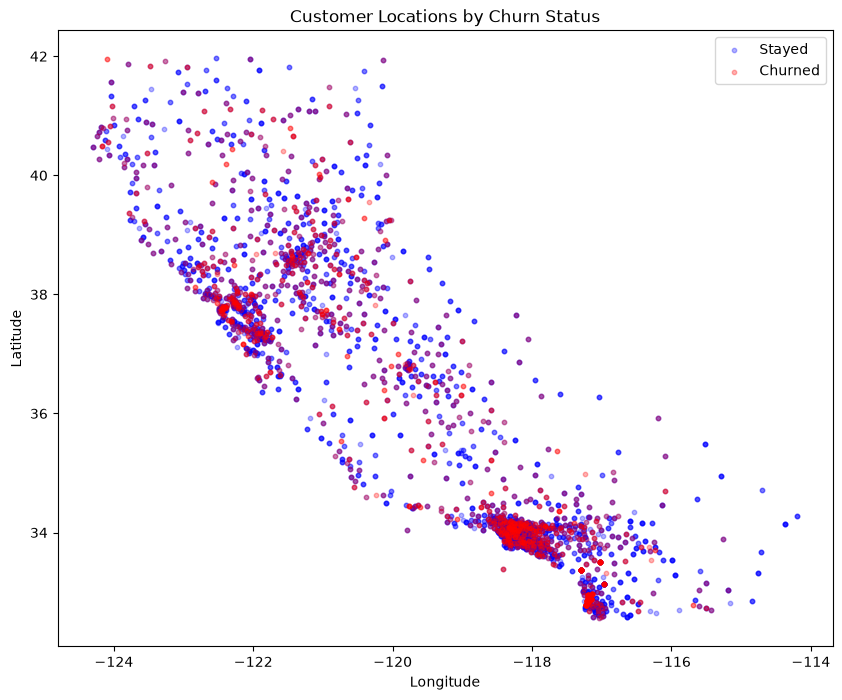

In [16]:
plt.figure(figsize=(10, 8))
plt.scatter(temp[temp['Churn']==0]['Longitude'], temp[temp['Churn']==0]['Latitude'],
            alpha=0.3, s=10, label='Stayed', color='blue')
plt.scatter(temp[temp['Churn']==1]['Longitude'], temp[temp['Churn']==1]['Latitude'],
            alpha=0.3, s=10, label='Churned', color='red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Customer Locations by Churn Status')
plt.legend()
plt.show()

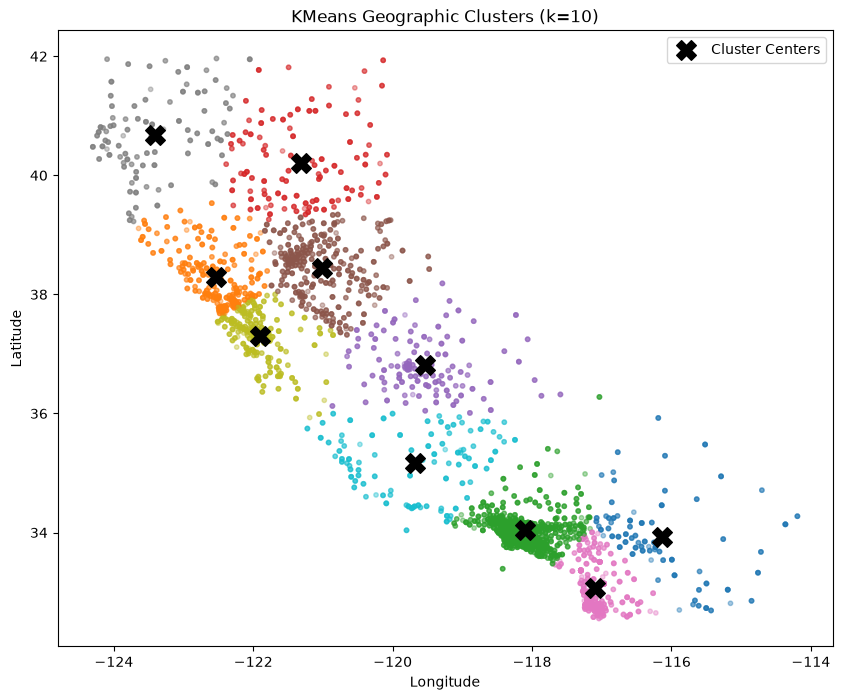

In [17]:
from sklearn.cluster import KMeans

coords = X_train[['Latitude', 'Longitude']].values

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(coords)

# visualize the clusters found
plt.figure(figsize=(10, 8))
plt.scatter(X_train['Longitude'], X_train['Latitude'], c=kmeans.labels_, cmap='tab10', alpha=0.4, s=10)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0],
            c='black', marker='X', s=200, label='Cluster Centers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('KMeans Geographic Clusters (k=10)')
plt.legend()
plt.show()

In [18]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

region_labels = kmeans.labels_          # each customer's assigned region (0-9)
churn = y_train['Churn'].values
gamma = 0.1

local_churn_score = np.full(len(X_train), np.nan)

for region in np.unique(region_labels):
    region_mask = region_labels == region
    region_idx = np.where(region_mask)[0]          # positions of customers in this region
    region_coords = coords[region_mask]
    region_churn = churn[region_mask]

    for local_i, global_i in enumerate(region_idx):
        # exclude the customer themself to avoid leakage
        others_mask = np.arange(len(region_idx)) != local_i
        other_coords = region_coords[others_mask]
        other_churn = region_churn[others_mask]

        churned_coords = other_coords[other_churn == 1]
        stayed_coords = other_coords[other_churn == 0]

        this_coord = region_coords[local_i].reshape(1, -1)

        sim_to_churned = rbf_kernel(this_coord, churned_coords, gamma=gamma).mean() if len(churned_coords) > 0 else 0
        sim_to_stayed = rbf_kernel(this_coord, stayed_coords, gamma=gamma).mean() if len(stayed_coords) > 0 else 0

        denom = sim_to_churned + sim_to_stayed
        local_churn_score[global_i] = sim_to_churned / denom if denom > 0 else np.nan

X_train_geo = X_train.copy()
X_train_geo['Region'] = region_labels
X_train_geo['Churn'] = churn
X_train_geo['Local_Churn_Proximity_Score'] = local_churn_score

X_train_geo[['Region', 'Churn', 'Local_Churn_Proximity_Score']].head(15)

,Region,Churn,Local_Churn_Proximity_Score
0,4,0,0.501832
1,9,0,0.496933
2,2,1,0.500374
3,2,1,0.500466
4,5,0,0.500508
5,2,0,0.500787
6,1,1,0.503888
7,4,0,0.506702
8,3,1,0.503596
9,2,0,0.500181


In [19]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

region_labels = kmeans.labels_
churn = y_train['Churn'].values
K = 15          # number of nearest neighbors to consider
gamma = 0.1     # controls how fast similarity decays with distance

local_churn_score = np.full(len(X_train), np.nan)

for region in np.unique(region_labels):
    region_mask = region_labels == region
    region_idx = np.where(region_mask)[0]        # global row positions in this region
    region_coords = coords[region_mask]
    region_churn = churn[region_mask]
    n_region = len(region_idx)

    # k+1 because the nearest neighbor to any point is itself (distance 0) - we'll drop it
    k_eff = min(K + 1, n_region)
    nn = NearestNeighbors(n_neighbors=k_eff).fit(region_coords)
    distances, neighbor_idx = nn.kneighbors(region_coords)

    for local_i in range(n_region):
        # drop the first neighbor (itself, distance=0) to avoid leakage
        neigh_dist = distances[local_i, 1:]
        neigh_pos = neighbor_idx[local_i, 1:]

        # RBF similarity weight from distance: closer neighbor = higher weight
        weights = np.exp(-gamma * neigh_dist**2)

        neigh_churn = region_churn[neigh_pos]

        # weighted local churn rate among this point's K nearest in-region neighbors
        denom = weights.sum()
        score = (weights * neigh_churn).sum() / denom if denom > 0 else np.nan

        local_churn_score[region_idx[local_i]] = score

X_train_geo = X_train.copy()
X_train_geo['Region'] = region_labels
X_train_geo['Churn'] = churn
X_train_geo['Local_Churn_KNN_Score'] = local_churn_score

X_train_geo[['Region', 'Churn', 'Local_Churn_KNN_Score']].describe()

,Region,Churn,Local_Churn_KNN_Score
count,5180.000000,5180.000000,5180.000000
mean,4.042664,0.283977,0.285517
std,2.592173,0.450969,0.153832
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.199989
50%,4.000000,0.000000,0.266666
75%,6.000000,1.000000,0.333343
max,9.000000,1.000000,0.933333


In [20]:

X_train_geo.groupby('Churn')['Local_Churn_KNN_Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,3709.0,0.259701,0.122499,0.0,0.199914,0.266632,0.333327,0.933333
1,1471.0,0.350609,0.198994,0.0,0.200265,0.333263,0.400018,0.933333


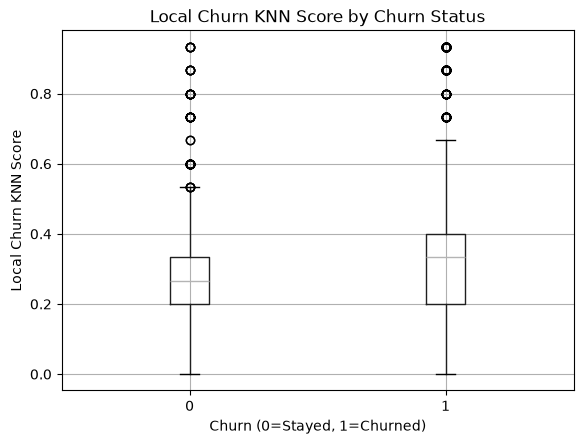

In [21]:
X_train_geo.boxplot(column='Local_Churn_KNN_Score', by='Churn')
plt.title('Local Churn KNN Score by Churn Status')
plt.suptitle('')
plt.xlabel('Churn (0=Stayed, 1=Churned)')
plt.ylabel('Local Churn KNN Score')
plt.show()

In [22]:
from sklearn.neighbors import NearestNeighbors

K = 15
gamma = 0.1

region_labels_train = kmeans.labels_          # region assignment for X_train (already computed)
churn_train = y_train['Churn'].values

# store one fitted NearestNeighbors model + its churn labels, per region
region_models = {}

for region in np.unique(region_labels_train):
    mask = region_labels_train == region
    region_coords_train = coords[mask]
    region_churn_train = churn_train[mask]

    nn = NearestNeighbors(n_neighbors=min(K, mask.sum())).fit(region_coords_train)
    region_models[region] = {
        'nn': nn,
        'coords': region_coords_train,
        'churn': region_churn_train
    }

print("Fitted KNN models for regions:", list(region_models.keys()))

Fitted KNN models for regions: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]


In [23]:
def compute_local_churn_score(query_coords, query_region_labels, region_models, gamma=0.1, exclude_self=False):
    """
    query_coords: array of (lat, long) for the points we want to score
    query_region_labels: which region each query point belongs to (from kmeans.predict)
    region_models: dict built from X_train (nn model + coords + churn per region)
    exclude_self: True when scoring X_train itself (leave-one-out), False for X_test
    """
    scores = np.full(len(query_coords), np.nan)

    for region, model_data in region_models.items():
        mask = query_region_labels == region
        if mask.sum() == 0:
            continue

        q_coords = query_coords[mask]
        nn = model_data['nn']
        pool_coords = model_data['coords']
        pool_churn = model_data['churn']

        k_search = nn.n_neighbors + 1 if exclude_self else nn.n_neighbors
        k_search = min(k_search, len(pool_coords))

        distances, neighbor_idx = NearestNeighbors(n_neighbors=k_search).fit(pool_coords).kneighbors(q_coords)

        region_scores = np.full(mask.sum(), np.nan)
        for i in range(mask.sum()):
            dist_row = distances[i]
            idx_row = neighbor_idx[i]

            if exclude_self:
                # drop the closest match (distance ~0, which is the point itself)
                dist_row = dist_row[1:]
                idx_row = idx_row[1:]

            weights = np.exp(-gamma * dist_row**2)
            neigh_churn = pool_churn[idx_row]

            denom = weights.sum()
            region_scores[i] = (weights * neigh_churn).sum() / denom if denom > 0 else np.nan

        scores[mask] = region_scores

    return scores

In [24]:
# --- X_train: leave-one-out (each point excludes itself from its own neighbor search) ---
X_train_geo['Local_Churn_KNN_Score_v2'] = compute_local_churn_score(
    query_coords=coords,
    query_region_labels=region_labels_train,
    region_models=region_models,
    gamma=gamma,
    exclude_self=True
)

# sanity check: should closely match our earlier validated score
print("Train score sanity check (mean by Churn):")
print(X_train_geo.groupby('Churn')['Local_Churn_KNN_Score_v2'].mean())
print()

# --- X_test: assign each test point to its nearest region using the SAME fitted kmeans ---
X_test = pd.read_csv('Data/X_test.csv')
test_coords = X_test[['Latitude', 'Longitude']].values
region_labels_test = kmeans.predict(test_coords)

X_test_geo = X_test.copy()
X_test_geo['Region'] = region_labels_test
X_test_geo['Local_Churn_KNN_Score'] = compute_local_churn_score(
    query_coords=test_coords,
    query_region_labels=region_labels_test,
    region_models=region_models,
    gamma=gamma,
    exclude_self=False   # test points were never in the training pool, so no self to exclude
)

X_test_geo[['Region', 'Local_Churn_KNN_Score']].describe()

Train score sanity check (mean by Churn):
Churn
0    0.259701
1    0.350609
Name: Local_Churn_KNN_Score_v2, dtype: float64



,Region,Local_Churn_KNN_Score
count,1295.000000,1295.000000
mean,4.006178,0.287272
std,2.642529,0.159884
min,0.000000,0.000000
25%,2.000000,0.199990
50%,3.000000,0.266667
75%,6.000000,0.333346
max,9.000000,0.933333


In [25]:
# Add the validated feature to the real X_train / X_test (not just the _geo copies)
X_train['Local_Churn_KNN_Score'] = X_train_geo['Local_Churn_KNN_Score_v2'].values
X_test['Local_Churn_KNN_Score'] = X_test_geo['Local_Churn_KNN_Score'].values

# quick confirmation
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()
print(X_train[['Latitude', 'Longitude', 'Local_Churn_KNN_Score']].head())

X_train shape: (5180, 33)
X_test shape: (1295, 33)

    Latitude   Longitude  Local_Churn_KNN_Score
0  36.545353 -119.338535               0.266755
1  35.480896 -120.469476               0.266396
2  34.083086 -117.737997               0.333339
3  34.049671 -117.468896               0.333326
4  38.148862 -121.737696               0.333340


## 10. Outlier detection

In [26]:
numeric_cols_check = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges',
                       'Total Revenue', 'Avg Monthly GB Download', 'Total Long Distance Charges']

for col in numeric_cols_check:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    print(f"{col:35s} outliers: {len(outliers):4d}  (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

Age                                 outliers:    0  (bounds: -7.50 to 100.50)
Tenure in Months                    outliers:    0  (bounds: -55.50 to 124.50)
Monthly Charge                      outliers:    0  (bounds: -25.98 to 160.87)
Total Charges                       outliers:    0  (bounds: -4681.75 to 9298.35)
Total Revenue                       outliers:    3  (bounds: -5640.50 to 11667.94)
Avg Monthly GB Download             outliers:  263  (bounds: -30.50 to 61.50)
Total Long Distance Charges         outliers:  103  (bounds: -1657.89 to 3059.41)


In [27]:
print("Avg Monthly GB Download - top outlier values:")
print(X_train['Avg Monthly GB Download'].sort_values(ascending=False).head(10))
print()
print("Total Long Distance Charges - top outlier values:")
print(X_train['Total Long Distance Charges'].sort_values(ascending=False).head(10))

Avg Monthly GB Download - top outlier values:
2149    85.0
14      85.0
2076    85.0
644     85.0
635     85.0
592     85.0
4496    85.0
487     85.0
1031    85.0
1966    85.0
Name: Avg Monthly GB Download, dtype: float64

Total Long Distance Charges - top outlier values:
3829    3564.72
3667    3564.00
4497    3536.64
797     3515.92
1785    3508.82
5136    3493.44
2388    3492.72
5042    3487.68
756     3481.92
238     3476.90
Name: Total Long Distance Charges, dtype: float64


## 11. Data quality confirmation

In [28]:
print("Negative Monthly Charge rows remaining:", (X_train['Monthly Charge'] < 0).sum())
print("X_train shape:", X_train.shape)

Negative Monthly Charge rows remaining: 0
X_train shape: (5180, 33)
